Using device: cuda



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/affine_loss_curve.png'

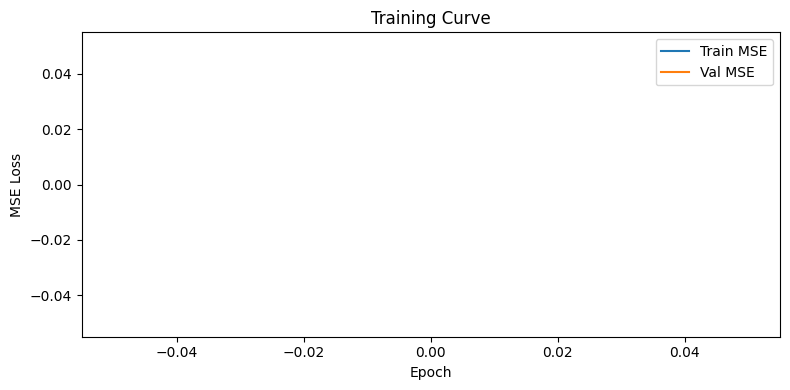

In [9]:
"""
Proof of Concept: Trainable Affine Transformations
===================================================
A network receives two images (img1, img2) where img2 = rotate(img1, θ).
It predicts a 2x3 affine matrix, applies it to img1 via grid_sample,
and minimises MSE against img2.

Because affine_grid + grid_sample are differentiable, gradients flow
back through the spatial transformation into the CNN weights.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader


# ─────────────────────────────────────────────
#  1. DATA GENERATION
# ─────────────────────────────────────────────

def make_circle_image(size=256):
    """
    Draw a single circle at a random position and radius on a blank canvas.
    Returns a float32 numpy array in [0, 1], shape (size, size).
    """
    img = np.zeros((size, size), dtype=np.float32)

    cx = np.random.randint(size // 4, 3 * size // 4)
    cy = np.random.randint(size // 4, 3 * size // 4)
    r  = np.random.randint(20, 60)

    y, x = np.ogrid[:size, :size]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    img[dist <= r] = 1.0
    return img


def rotate_image_np(img, angle_deg):
    """
    Rotate a numpy (H, W) image by angle_deg degrees (counter-clockwise)
    using an affine warp — same math the network will learn.
    """
    angle_rad = np.deg2rad(angle_deg)
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

    # Build 2x3 matrix for torch (maps output coords → input coords)
    theta = np.array([
        [ cos_a, sin_a, 0.0],
        [-sin_a, cos_a, 0.0],
    ], dtype=np.float32)

    t = torch.tensor(theta).unsqueeze(0)                  # (1, 2, 3)
    x = torch.tensor(img).unsqueeze(0).unsqueeze(0)       # (1, 1, H, W)
    grid = F.affine_grid(t, x.shape, align_corners=False)
    out  = F.grid_sample(x, grid, align_corners=False, padding_mode="zeros")
    return out.squeeze().numpy()


class CircleRotationDataset(Dataset):
    """
    Each sample: (img1, img2, theta_gt)
      - img1 : original circle image
      - img2 : img1 rotated by a random angle in [-45°, +45°]
      - theta_gt : ground-truth 2x3 affine matrix (for reference / debugging)
    """
    def __init__(self, n_samples=4000, img_size=256, angle_range=45):
        self.n_samples   = n_samples
        self.img_size    = img_size
        self.angle_range = angle_range

        self.img1s      = []
        self.img2s      = []
        self.thetas_gt  = []

        for _ in range(n_samples):
            img1  = make_circle_image(img_size)
            angle = np.random.uniform(-angle_range, angle_range)
            img2  = rotate_image_np(img1, angle)

            rad   = np.deg2rad(angle)
            cos_a, sin_a = np.cos(rad), np.sin(rad)
            gt = np.array([[ cos_a, sin_a, 0.],
                            [-sin_a, cos_a, 0.]], dtype=np.float32)

            self.img1s.append(img1)
            self.img2s.append(img2)
            self.thetas_gt.append(gt)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img1 = torch.tensor(self.img1s[idx]).unsqueeze(0)     # (1, H, W)
        img2 = torch.tensor(self.img2s[idx]).unsqueeze(0)     # (1, H, W)
        gt   = torch.tensor(self.thetas_gt[idx])              # (2, 3)
        return img1, img2, gt


# ─────────────────────────────────────────────
#  2. NETWORK
# ─────────────────────────────────────────────

class AffineRegressor(nn.Module):
    """
    CNN that receives two images (concatenated → 2 channels) and
    regresses the 6 parameters of a 2×3 affine matrix.

    Architecture
    ────────────
    4× Conv-BN-ReLU blocks (with stride-2 downsampling) →
    Global average pooling →
    Two FC layers →
    6 outputs (reshaped to 2×3)

    Weight initialisation
    ─────────────────────
    The final layer is initialised to the identity transform
    [1 0 0 / 0 1 0] so training starts from a sensible baseline.
    """
    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.encoder = nn.Sequential(
            conv_block(2,   32),   # 256 → 128
            conv_block(32,  64),   # 128 →  64
            conv_block(64, 128),   #  64 →  32
            conv_block(128, 256),  #  32 →  16
        )

        self.pool = nn.AdaptiveAvgPool2d(1)  # (B, 256, 1, 1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 6),
        )

        # Initialise last layer → identity transform
        self.regressor[-1].weight.data.zero_()
        self.regressor[-1].bias.data.copy_(
            torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float32)
        )

    def forward(self, img1, img2):
        """
        img1, img2 : (B, 1, H, W)
        returns     : warped_img1 (B, 1, H, W), theta (B, 2, 3)
        """
        x     = torch.cat([img1, img2], dim=1)      # (B, 2, H, W)
        feats = self.pool(self.encoder(x))           # (B, 256, 1, 1)
        theta = self.regressor(feats).view(-1, 2, 3) # (B, 2, 3)

        # Apply the predicted affine transform to img1
        grid        = F.affine_grid(theta, img1.size(), align_corners=False)
        warped_img1 = F.grid_sample(img1, grid, align_corners=False,
                                    padding_mode="zeros")
        return warped_img1, theta


# ─────────────────────────────────────────────
#  3. TRAINING
# ─────────────────────────────────────────────

def train(n_epochs=20, batch_size=32, lr=1e-3, n_samples=4000):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")

    dataset    = CircleRotationDataset(n_samples=n_samples)
    val_size   = int(0.1 * len(dataset))
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [len(dataset) - val_size, val_size]
    )
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    model = AffineRegressor().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):
        # ── train ──
        model.train()
        running = 0.0
        for img1, img2, _ in train_dl:
            img1, img2 = img1.to(device), img2.to(device)
            warped, _  = model(img1, img2)
            loss = F.mse_loss(warped, img2)

            opt.zero_grad()
            loss.backward()
            opt.step()
            running += loss.item() * img1.size(0)

        train_loss = running / len(train_ds)

        # ── validate ──
        model.eval()
        running = 0.0
        with torch.no_grad():
            for img1, img2, _ in val_dl:
                img1, img2 = img1.to(device), img2.to(device)
                warped, _  = model(img1, img2)
                running   += F.mse_loss(warped, img2).item() * img1.size(0)

        val_loss = running / len(val_ds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        sched.step()

        print(f"Epoch {epoch:3d}/{n_epochs}  "
              f"train_mse={train_loss:.5f}  val_mse={val_loss:.5f}")

    return model, train_losses, val_losses, dataset, device


# ─────────────────────────────────────────────
#  4. VISUALISATION
# ─────────────────────────────────────────────

def visualise(model, dataset, device, n_show=4):
    model.eval()
    fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5 * n_show))
    cols = ["Image 1 (source)", "Image 2 (target)", "Warped Image 1", "Difference"]

    indices = np.random.choice(len(dataset), n_show, replace=False)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img1, img2, gt = dataset[idx]
            img1_b = img1.unsqueeze(0).to(device)
            img2_b = img2.unsqueeze(0).to(device)
            warped_b, theta = model(img1_b, img2_b)

            img1_np   = img1.squeeze().numpy()
            img2_np   = img2.squeeze().numpy()
            warped_np = warped_b.squeeze().cpu().numpy()
            diff_np   = np.abs(warped_np - img2_np)

            theta_np = theta.squeeze().cpu().numpy()
            gt_np    = gt.numpy()

            # Decode predicted vs ground-truth angle
            pred_angle = np.rad2deg(np.arctan2(-theta_np[1, 0], theta_np[0, 0]))
            gt_angle   = np.rad2deg(np.arctan2(-gt_np[1, 0],   gt_np[0, 0]))

            for col, (arr, title) in enumerate(zip(
                [img1_np, img2_np, warped_np, diff_np], cols
            )):
                ax = axes[row][col]
                cmap = "hot" if col == 3 else "gray"
                ax.imshow(arr, cmap=cmap, vmin=0, vmax=1)
                ax.axis("off")
                if row == 0:
                    ax.set_title(title, fontsize=12, fontweight="bold")
                if col == 2:
                    ax.set_xlabel(
                        f"pred={pred_angle:.1f}°  gt={gt_angle:.1f}°",
                        fontsize=9, labelpad=3
                    )
                    ax.xaxis.set_visible(True)
                    ax.set_xticks([])

    plt.suptitle("Affine Registration Results", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    # plt.savefig("/mnt/user-data/outputs/affine_results.png", dpi=120, bbox_inches="tight")
    # print("Saved: affine_results.png")


def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train MSE")
    plt.plot(val_losses,   label="Val MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/affine_loss_curve.png", dpi=120)
    print("Saved: affine_loss_curve.png")


# ─────────────────────────────────────────────
#  5. ENTRY POINT
# ─────────────────────────────────────────────

model, train_losses, val_losses, dataset, device = train(
    n_epochs=0,
    batch_size=32,
    lr=1e-3,
    n_samples=4000,
)
plot_losses(train_losses, val_losses)
visualise(model, dataset, device)

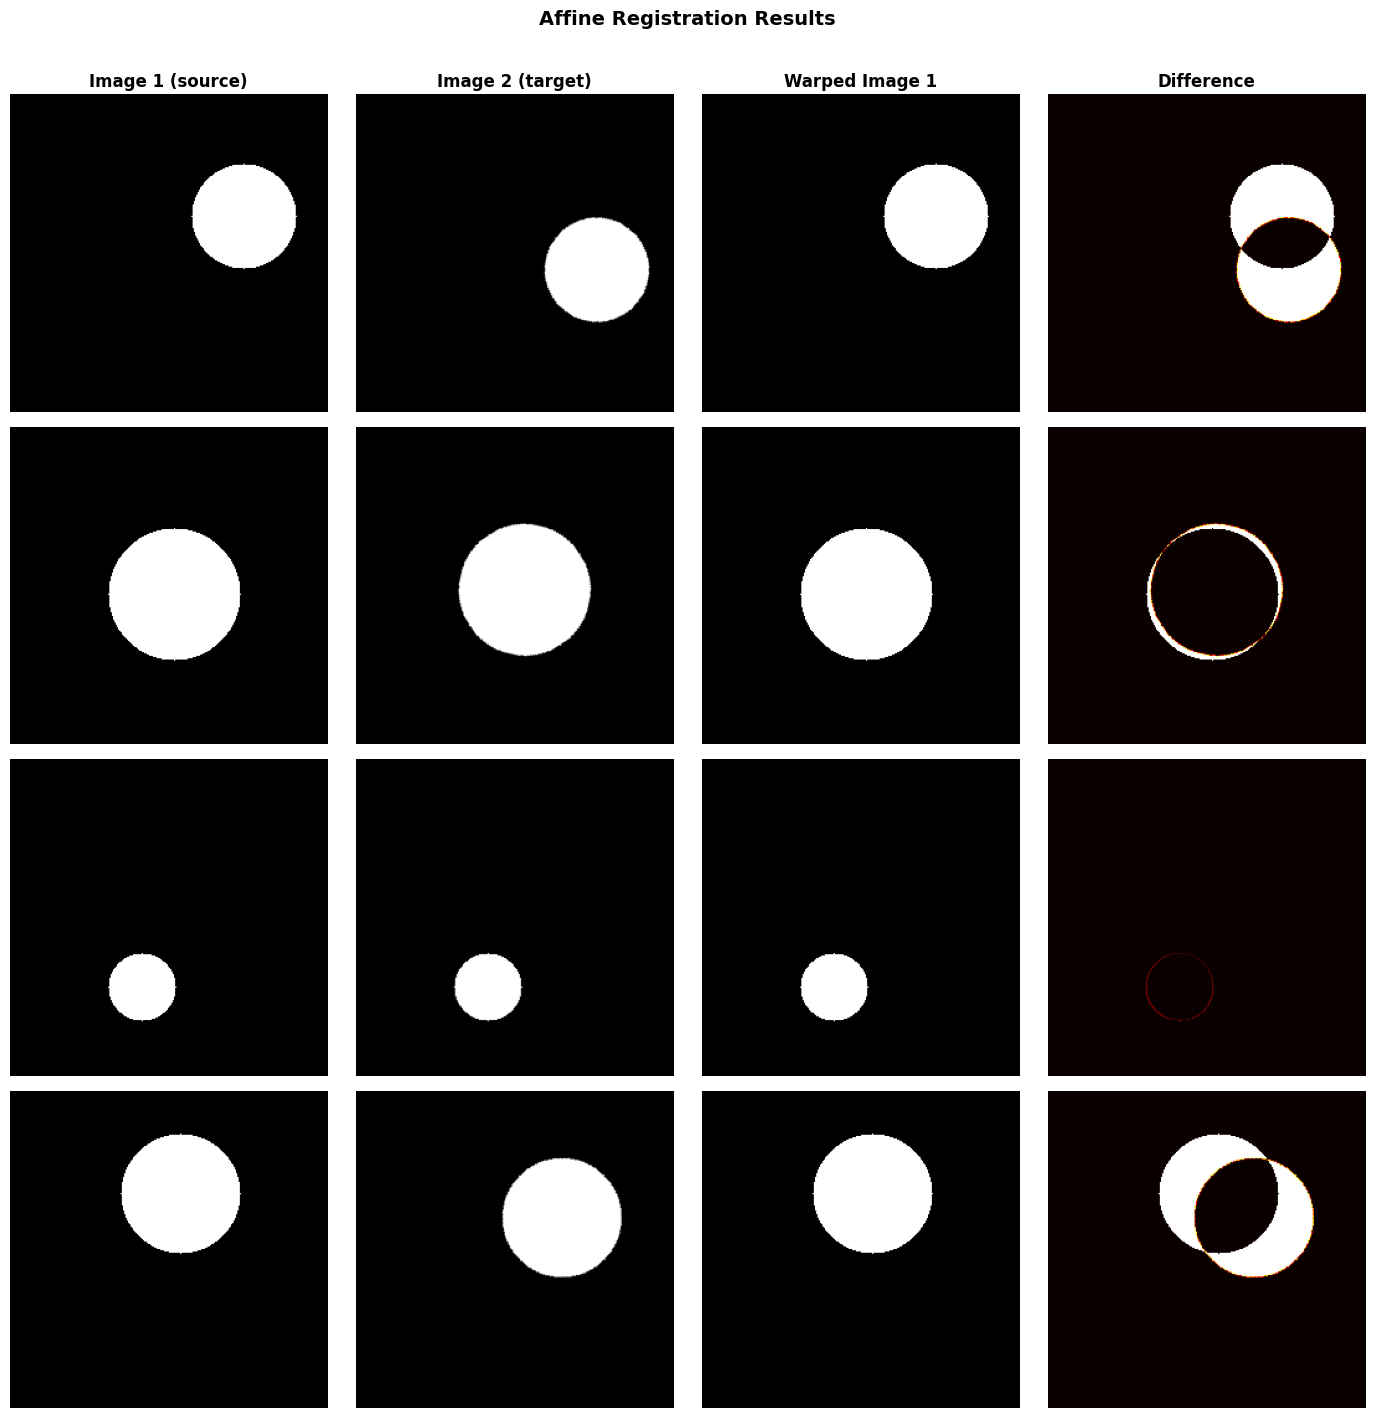

In [11]:

def visualise(model, dataset, device, n_show=4):
    model.eval()
    fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5 * n_show))
    cols = ["Image 1 (source)", "Image 2 (target)", "Warped Image 1", "Difference"]

    indices = np.random.choice(len(dataset), n_show, replace=False)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img1, img2, gt = dataset[idx]
            img1_b = img1.unsqueeze(0).to(device)
            img2_b = img2.unsqueeze(0).to(device)
            warped_b, theta = model(img1_b, img2_b)

            img1_np   = img1.squeeze().numpy()
            img2_np   = img2.squeeze().numpy()
            warped_np = warped_b.squeeze().cpu().numpy()
            diff_np   = np.abs(warped_np - img2_np)

            theta_np = theta.squeeze().cpu().numpy()
            gt_np    = gt.numpy()

            # Decode predicted vs ground-truth angle
            pred_angle = np.rad2deg(np.arctan2(-theta_np[1, 0], theta_np[0, 0]))
            gt_angle   = np.rad2deg(np.arctan2(-gt_np[1, 0],   gt_np[0, 0]))

            for col, (arr, title) in enumerate(zip(
                [img1_np, img2_np, warped_np, diff_np], cols
            )):
                ax = axes[row][col]
                cmap = "hot" if col == 3 else "gray"
                ax.imshow(arr, cmap=cmap, vmin=0, vmax=1)
                ax.axis("off")
                if row == 0:
                    ax.set_title(title, fontsize=12, fontweight="bold")
                if col == 2:
                    ax.set_xlabel(
                        f"pred={pred_angle:.1f}°  gt={gt_angle:.1f}°",
                        fontsize=9, labelpad=3
                    )
                    ax.xaxis.set_visible(True)
                    ax.set_xticks([])

    plt.suptitle("Affine Registration Results", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

visualise(model, dataset, device)